# CN5 - Synthesis 

The “from map(s)” or “from stats” syntheses include by default the integration of the power spectrum into the representation vectors $\phi$ used in the loss, in addition to the scattering coefficients.
The loss is defined as:
$$
\mathcal{L}
=
\left\|\phi(\text{target}) - \phi(\text{running})\right\|_2.
$$

Here, we are interested in investigating whether the isotropic power spectrum can be recovered without explicitly including it in the loss, relying solely on the $S_2$ scattering coefficients.

In [2]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
from pathlib import Path
import sys

from types import SimpleNamespace

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# Force device ("cuda", "cpu", "mps")
#import STL_main.torch_backend as bk
#bk._DEFAULT_DEVICE = torch.device("cpu")

# STL package imports
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
from STL_main.Synthesis import synthesize_from_maps
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: cpu


In [3]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [4]:
def plot_target_vs_synthesis(target, synthesis, suptitle, titles=["Target", "Synthesis"]):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    t = target.cpu().numpy()
    u = synthesis.cpu().numpy()

    # Color scale limits of the target image, ignoring NaNs
    mean_t = np.nanmean(t)
    std_t = np.nanstd(t)

    vmin = mean_t - 3 * std_t
    vmax = mean_t + 3 * std_t

    im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[0].axis("off")
    axes[0].set_title(titles[0])

    im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[1].axis("off")
    axes[1].set_title(titles[1])

    fig.colorbar(im0, ax=axes, shrink=0.7)

    fig.suptitle(suptitle, fontsize=16)

    plt.show()

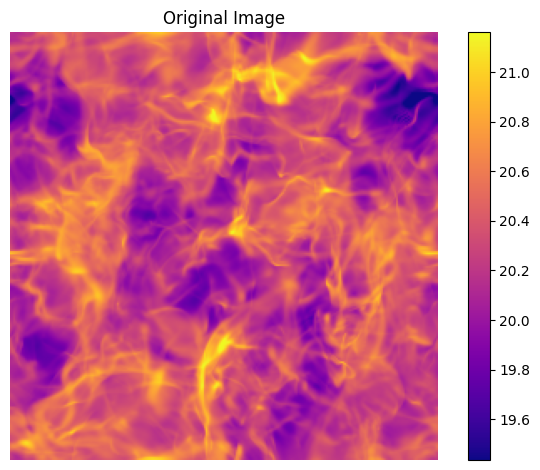

In [5]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Display original image
im_plot = plt.imshow(
    im[0, 0, :, :],
    cmap="plasma",
    vmin=np.nanmean(im) - 3 * np.nanstd(im),
    vmax=np.nanmean(im) + 3 * np.nanstd(im)
)
plt.title("Original Image")
plt.axis('off')
plt.colorbar(im_plot)
plt.tight_layout()
plt.show()

In [6]:
im_target = im[0, 0, :, :] # Target image (mono-channel)

# Instantiate FFT data class on the target image
data_target_fft = STL_2D_FFT_Torch(im_target, pbc=True)

# Call user-level synthesis-from-maps wrapper
u_fft = synthesize_from_maps(
    data_target_fft,
    nbatch=1,
    pbc_running=True
)

u_fft = STL_2D_FFT_Torch(u_fft, pbc=True)

Running synthesis on device: cpu dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Prefiltering target to remove frequencies above Nyquist
Synthesis on 3970 ST coefficients
Prefiltering initial map to remove frequencies above Nyquist
[LBFGS] iter 10, loss = 1.336921e+03
[LBFGS] iter 20, loss = 2.831641e+01
[LBFGS] iter 30, loss = 2.070549e+01
[LBFGS] iter 40, loss = 7.663906e+00
[LBFGS] iter 50, loss = 4.006301e+00
[LBFGS] iter 60, loss = 2.618261e+00
[LBFGS] iter 70, loss = 1.633566e+00
[LBFGS] iter 80, loss = 1.239681e+00
[LBFGS] iter 90, loss = 1.008518e+00
[LBFGS] iter 100, loss = 8.520904e-01
[LBFGS] iter 110, loss = 7.381084e-01
111 iterations of synthesis.
Execution time: 88.511 s


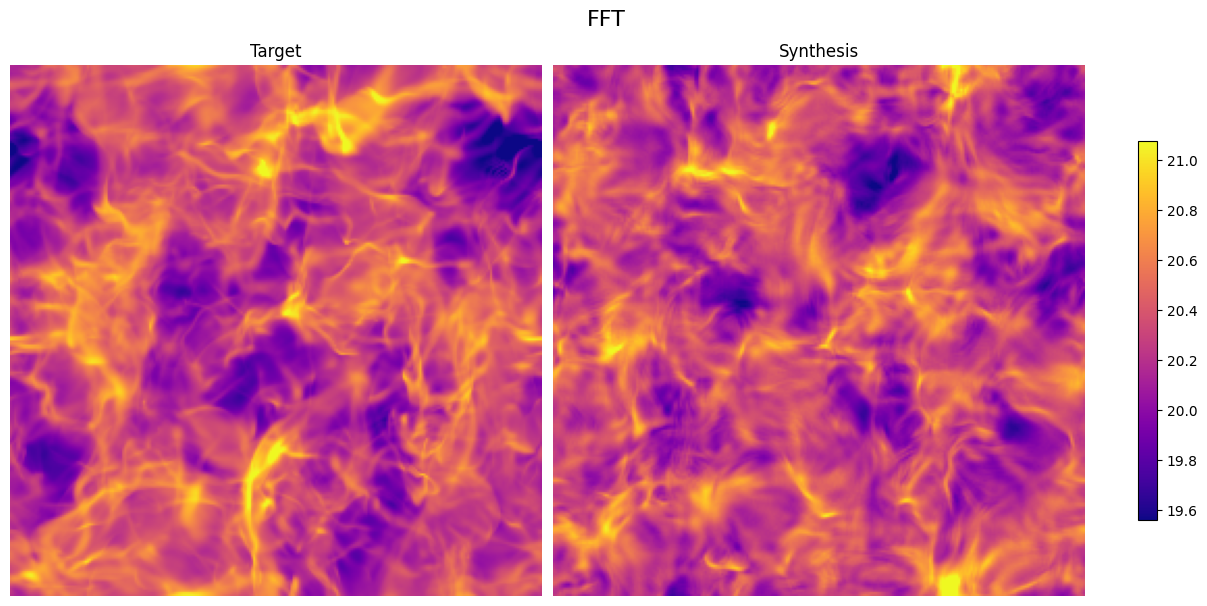

In [7]:
plot_target_vs_synthesis(data_target_fft.array, u_fft.array, suptitle = "FFT", titles=["Target", "Synthesis"])

In [46]:
import numpy as np
import torch


def estimate_radial_psd(x: torch.Tensor):
    """
    Fined and linearly spaced estimate of the radial power spectral density
    """
    
    H, W = x.shape[-2], x.shape[-1]
    device = x.device

    # Grid
    ky = torch.fft.fftfreq(H, device=device) * H
    kx = torch.fft.fftfreq(W, device=device) * W
    grid_y, grid_x = torch.meshgrid(ky, kx, indexing="ij")

    # Discrete Euclidean radius rounded to the nearest integer
    r = torch.round(torch.sqrt(grid_x**2 + grid_y**2)).long()

    # Maximum isotropic frequency (Nyquist on the smallest side)
    k_max = min(H, W) // 2   
    mask = r <= k_max

    # 2. 2D periodogram (squared magnitude of the 2D FFT)
    fft_x = torch.fft.fft2(x)
    psd_2d = torch.abs(fft_x) ** 2

    # 3. Sum and count per 1-pixel ring using bincount
    r_masked = r[mask]
    psd_masked = psd_2d[mask]

    power_sum = torch.bincount(r_masked, weights=psd_masked, minlength=k_max + 1)
    pixel_count = torch.bincount(r_masked, minlength=k_max + 1)

    # 4. Angular average per radius
    psd_radial = power_sum / torch.clamp(pixel_count, min=1)
    k = torch.arange(k_max + 1, device=device)
 
    return k, psd_radial

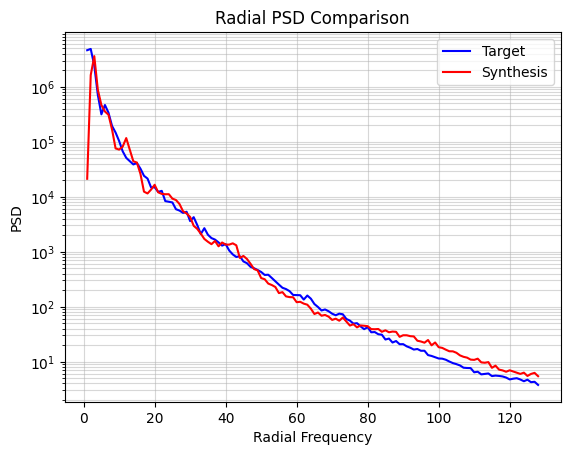

In [9]:
k_target, psd_target = estimate_radial_psd(data_target_fft.array)
k_synthesis, psd_synthesis = estimate_radial_psd(u_fft.array)

plt.figure()
plt.plot(k_target, psd_target, label="Target", color="blue")
plt.plot(k_synthesis, psd_synthesis, label="Synthesis", color="red")
plt.yscale("log")
plt.xlabel("Radial Frequency")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title("Radial PSD Comparison")
plt.legend()
plt.show()

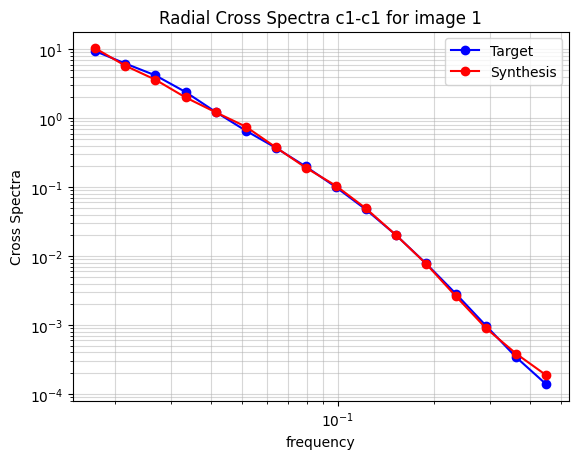

In [10]:
# Let's plot PSD of the target and synthesized image
cs_op = data_target_fft.get_CS_op()
psd_target = cs_op.apply(data_target_fft)
psd_u = cs_op.apply(u_fft)

cs_op.plot_cross_spectrum(psd_target.real, b=0, c1=0, c2=0, label="Target", color="b")
cs_op.plot_cross_spectrum(psd_u.real, b=0, c1=0, c2=0, label="Synthesis", color="r")

The next idea is to whiten the power spectrum of the target image and then optimize the scattering coefficients on the whitened image.

In this way, within the bandwidth of a given wavelet, we optimize the running image so that it has the same power spectrum across the entire bandwidth. Otherwise, for natural images whose power spectrum typically decays as $1/k^\gamma$, only the beginning of the power spectrum within a wavelet band is correctly synthesized: the rest becomes negligible, while still allowing the scattering coefficients to match well.

In a second step, we then need to de-whiten the power spectrum of the synthesized image.

In [ ]:
def whiten_spectrum(x, eps=1e-12):
    """
    Whiten the Fourier spectrum of a 2D signal using an isotropic
    1D radial power spectral density estimate.

    Parameters
    ----------
    x : torch.Tensor
        2D input tensor of shape (N, N) in the spatial domain.

    eps : float, optional
        Small positive value to avoid division by zero.

    Returns
    -------
    x_white : torch.Tensor
        Whitened signal in the spatial domain.
    """

    _, psd_1d = estimate_radial_psd(x)

    N = x.shape[-1]

    # Fourier transform
    x_fft = torch.fft.fft2(x, norm="ortho")

    # Frequency coordinates in cycles per image
    freq = torch.fft.fftfreq(N, device=x.device) * N

    kx, ky = torch.meshgrid(freq, freq, indexing="ij")

    # Radial frequency
    k_radius = torch.sqrt(kx**2 + ky**2)

    # Radial bin index
    bin_index = torch.floor(k_radius).long()

    # Whitening mask
    psd_2d = torch.ones_like(x_fft.real)

    mask = bin_index < len(psd_1d)

    psd_2d[mask] = psd_1d[bin_index[mask]]
   
    # Whitening
    x_fft_white = x_fft / torch.sqrt(psd_2d + eps)

    # Back to spatial domain
    x_white = torch.fft.ifft2(x_fft_white, norm="ortho").real
    
    return x_white

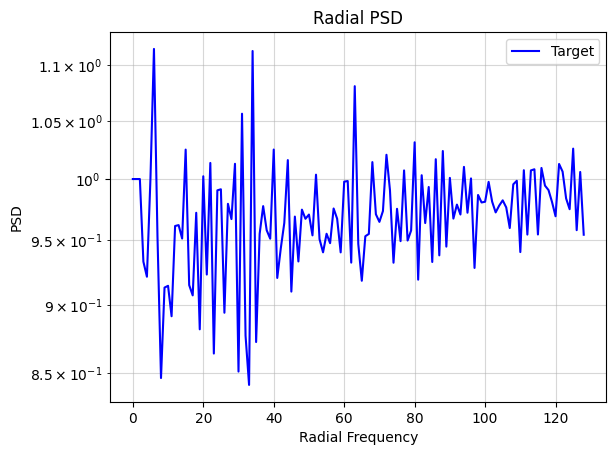

In [70]:
data_white_fft_array = whiten_spectrum(data_target_fft.array)
data_white_fft = STL_2D_FFT_Torch(data_white_fft_array, pbc=True)

k_data_white_array, psd_data_white_array = estimate_radial_psd(data_white_fft_array)

plt.figure()
plt.plot(k_data_white_array, psd_data_white_array, label="Target", color="blue")
plt.yscale("log")
plt.xlabel("Radial Frequency")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title("Radial PSD")
plt.legend()
plt.show()

In [71]:
# Call user-level synthesis-from-maps wrapper
u_white_fft = synthesize_from_maps(
    data_white_fft,
    nbatch=1,
    pbc_running=True
)

u_white_fft = STL_2D_FFT_Torch(u_white_fft, pbc=True)

Running synthesis on device: cpu dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Prefiltering target to remove frequencies above Nyquist
Synthesis on 3970 ST coefficients
Prefiltering initial map to remove frequencies above Nyquist
[LBFGS] iter 10, loss = 1.630647e+01
[LBFGS] iter 20, loss = 1.176339e+01
[LBFGS] iter 30, loss = 6.954950e+00
[LBFGS] iter 40, loss = 3.728675e+00
[LBFGS] iter 50, loss = 2.330363e+00
[LBFGS] iter 60, loss = 1.372467e+00
[LBFGS] iter 70, loss = 9.137731e-01
[LBFGS] iter 80, loss = 6.687158e-01
[LBFGS] iter 90, loss = 5.384764e-01
[LBFGS] iter 100, loss = 4.385408e-01
103 iterations of synthesis.
Execution time: 65.127 s


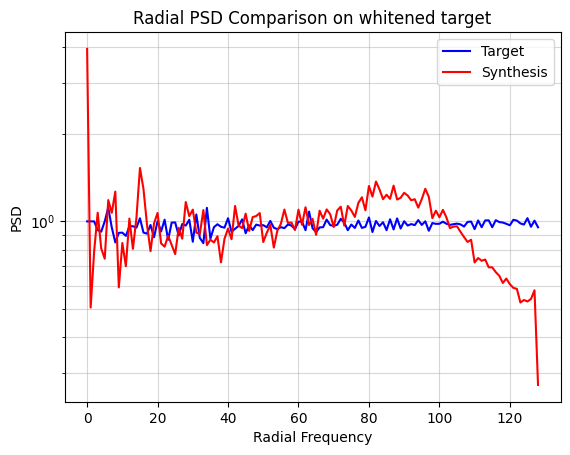

In [72]:
k_target, psd_target = estimate_radial_psd(data_white_fft.array)
k_synthesis, psd_synthesis = estimate_radial_psd(u_white_fft.array)

plt.figure()
plt.plot(k_target, psd_target, label="Target", color="blue")
plt.plot(k_synthesis, psd_synthesis, label="Synthesis", color="red")
plt.yscale("log")
plt.xlabel("Radial Frequency")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title("Radial PSD Comparison on whitened target")
plt.legend()
plt.show()